# Generate Paper Figures — Final Mouse Model (Run 9)

Generates all 6 figures for the ablation study paper using the final
Run 9 model (`final-200ep`, 79.1% mIoU sliding window, 96.9% accuracy).

**Figures:**
1. Architecture diagram (DINOv2-Large + UperNet)
2. Segmentation examples — 4×3 grid (Input / Ground Truth / Prediction)
3. Ablation bar chart — impact of each intervention on mIoU
4. IoU distribution — histogram + pixel count scatter
5. Cross-axis generalization — coronal vs axial vs sagittal predictions
6. Sliding window vs center-crop comparison

**Requirements:** GPU cluster (L40S or similar) + project wheel installed.
All figures are saved to `/dbfs/FileStore/allen_brain_data/figures/` and
displayed inline.

In [0]:
# Cell 0 — Install project wheel from DBFS

%pip install /dbfs/FileStore/wheels/histological_image_analysis-0.1.0-py3-none-any.whl
dbutils.library.restartPython()

Processing /dbfs/FileStore/wheels/histological_image_analysis-0.1.0-py3-none-any.whl
  Using cached accelerate-1.13.0-py3-none-any.whl.metadata (19 kB)
  Using cached nibabel-5.4.2-py3-none-any.whl.metadata (8.9 kB)
  Using cached pynrrd-1.1.3-py3-none-any.whl.metadata (5.4 kB)
  Using cached svgpathtools-1.7.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached svgwrite-1.4.3-py3-none-any.whl.metadata (8.8 kB)
Using cached accelerate-1.13.0-py3-none-any.whl (383 kB)
Using cached nibabel-5.4.2-py3-none-any.whl (3.3 MB)
Using cached pynrrd-1.1.3-py3-none-any.whl (23 kB)
Using cached svgpathtools-1.7.2-py2.py3-none-any.whl (68 kB)
Using cached svgwrite-1.4.3-py3-none-any.whl (67 kB)
  Attempting uninstall: accelerate
    Found existing installation: accelerate 1.5.2
    Not uninstalling accelerate at /databricks/python3/lib/python3.12/site-packages, outside environment /local_disk0/.ephemeral_nfs/envs/pythonEnv-3cec2ca4-e8d0-48dd-af04-7f2060133b3e
    Can't uninstall 'accelerate'. No fi

In [0]:
# Cell 1 — Configuration
#
# All environment-specific paths and constants.

import os

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# ---------- Databricks paths ----------
WORKSPACE_BASE = "/Workspace/Users/noel.nosse@grainger.com/visual-model-ft/histology"
ONTOLOGY_PATH = f"{WORKSPACE_BASE}/ontology/structure_graph_1.json"
ANNOTATION_10_PATH = f"{WORKSPACE_BASE}/ccfv3/annotation_10.nrrd"
NISSL_10_PATH = "/dbfs/FileStore/allen_brain_data/ccfv3/ara_nissl_10.nrrd"

# ---------- Model ----------
MODEL_DIR = "/dbfs/FileStore/allen_brain_data/models/final-200ep"

# ---------- Output ----------
FIGURES_DIR = "/dbfs/FileStore/allen_brain_data/figures"
os.makedirs(FIGURES_DIR, exist_ok=True)

# ---------- Constants ----------
CROP_SIZE = 518
SPLIT_STRATEGY = "interleaved"
MAPPING_TYPE = "full"
DPI = 300
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

print(f"Model:   {MODEL_DIR}")
print(f"Figures: {FIGURES_DIR}")
print(f"DPI:     {DPI}")

Model:   /dbfs/FileStore/allen_brain_data/models/final-200ep
Figures: /dbfs/FileStore/allen_brain_data/figures
DPI:     300


In [0]:
# Cell 2 — Load data pipeline
#
# OntologyMapper -> CCFv3Slicer -> BrainSegmentationDataset (val only)

from histological_image_analysis.ontology import OntologyMapper
from histological_image_analysis.ccfv3_slicer import CCFv3Slicer
from histological_image_analysis.dataset import BrainSegmentationDataset

mapper = OntologyMapper(ONTOLOGY_PATH)
mapping = mapper.build_full_mapping()
NUM_LABELS = mapper.get_num_labels(mapping)
class_names = mapper.get_class_names(mapping)
print(f"Full mapping: {NUM_LABELS} classes")

slicer = CCFv3Slicer(
    image_path=NISSL_10_PATH,
    annotation_path=ANNOTATION_10_PATH,
    ontology_mapper=mapper,
)
slicer.load_volumes()
print(f"Volume shape: {slicer.image_volume.shape}")

splits = slicer.get_split_indices(
    train_frac=0.8, val_frac=0.1, split_strategy=SPLIT_STRATEGY,
)
print(f"Train: {len(splits['train'])} | Val: {len(splits['val'])} | Test: {len(splits['test'])}")

val_ds = BrainSegmentationDataset(
    slicer=slicer, split="val", mapping=mapping,
    crop_size=CROP_SIZE, augment=False, split_strategy=SPLIT_STRATEGY,
)
print(f"Val samples: {len(val_ds)}")

Full mapping: 1328 classes
Volume shape: (1320, 800, 1140)
Train: 1016 | Val: 127 | Test: 127
Val samples: 127


In [0]:
# Cell 3 — Load final model from DBFS

import torch
from transformers import UperNetForSemanticSegmentation

model = UperNetForSemanticSegmentation.from_pretrained(MODEL_DIR)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

total_params = sum(p.numel() for p in model.parameters())
print(f"Model loaded on {device} ({total_params:,} params)")
print(f"Config: {model.config.num_labels} labels")

2026-03-18 01:06:25.549613: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773795985.565663    9048 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773795985.570584    9048 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773795985.584549    9048 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773795985.584563    9048 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773795985.584566    9048 computation_placer.cc:177] computation placer alr

[2026-03-18 01:06:32,263] [INFO] [real_accelerator.py:239:get_accelerator] Setting ds_accelerator to cuda (auto detect)


df: /root/.triton/autotune: No such file or directory
/usr/bin/ld: cannot find -laio: No such file or directory
collect2: error: ld returned 1 exit status
/usr/bin/ld: cannot find -lcufile: No such file or directory
collect2: error: ld returned 1 exit status


Model loaded on cuda (342,104,160 params)
Config: 1328 labels


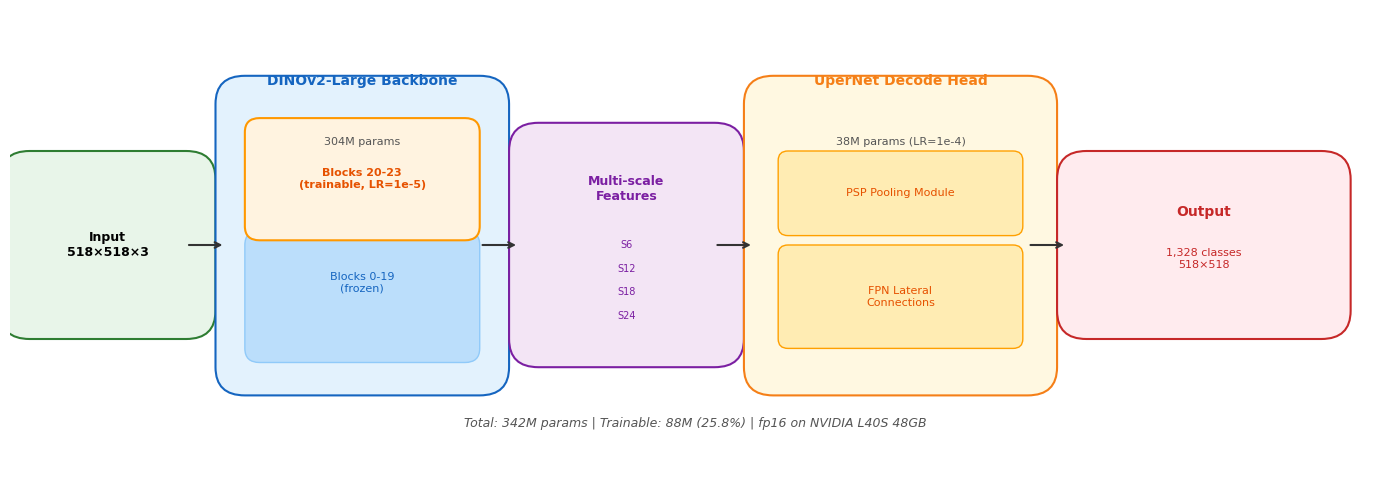

Saved: /dbfs/FileStore/allen_brain_data/figures/fig1_architecture.png


In [0]:
# Cell 4 — Figure 1: Architecture Diagram
#
# DINOv2-Large (24 blocks, last 4 unfrozen) + UperNet decode head.
# Pure matplotlib — no model or data required.

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(1, 1, figsize=(14, 5))
ax.set_xlim(0, 14)
ax.set_ylim(0, 5)
ax.axis("off")

box_style = dict(boxstyle="round,pad=0.3", linewidth=1.5)

# Input
ax.add_patch(mpatches.FancyBboxPatch(
    (0.2, 1.8), 1.6, 1.4, **box_style, facecolor="#E8F5E9", edgecolor="#2E7D32",
))
ax.text(1.0, 2.5, "Input\n518\u00d7518\u00d73", ha="center", va="center",
        fontsize=9, fontweight="bold")

ax.annotate("", xy=(2.2, 2.5), xytext=(1.8, 2.5),
            arrowprops=dict(arrowstyle="->", lw=1.5, color="#333"))

# DINOv2 backbone
bx = 2.4
ax.add_patch(mpatches.FancyBboxPatch(
    (bx, 1.2), 2.4, 2.8, **box_style, facecolor="#E3F2FD", edgecolor="#1565C0",
))
ax.text(bx + 1.2, 4.25, "DINOv2-Large Backbone", ha="center", va="center",
        fontsize=10, fontweight="bold", color="#1565C0")
ax.text(bx + 1.2, 3.6, "304M params", ha="center", va="center",
        fontsize=8, color="#555")

ax.add_patch(mpatches.FancyBboxPatch(
    (bx + 0.15, 1.4), 2.1, 1.1, boxstyle="round,pad=0.15",
    facecolor="#BBDEFB", edgecolor="#90CAF9", linewidth=1,
))
ax.text(bx + 1.2, 2.1, "Blocks 0-19\n(frozen)", ha="center", va="center",
        fontsize=8, color="#1565C0")

ax.add_patch(mpatches.FancyBboxPatch(
    (bx + 0.15, 2.7), 2.1, 1.0, boxstyle="round,pad=0.15",
    facecolor="#FFF3E0", edgecolor="#FF9800", linewidth=1.5,
))
ax.text(bx + 1.2, 3.2, "Blocks 20-23\n(trainable, LR=1e-5)", ha="center",
        va="center", fontsize=8, fontweight="bold", color="#E65100")

ax.annotate("", xy=(5.2, 2.5), xytext=(4.8, 2.5),
            arrowprops=dict(arrowstyle="->", lw=1.5, color="#333"))

# Feature maps
fx = 5.4
ax.add_patch(mpatches.FancyBboxPatch(
    (fx, 1.5), 1.8, 2.0, **box_style, facecolor="#F3E5F5", edgecolor="#7B1FA2",
))
ax.text(fx + 0.9, 3.1, "Multi-scale\nFeatures", ha="center", va="center",
        fontsize=9, fontweight="bold", color="#7B1FA2")
for i, stage in enumerate(["S6", "S12", "S18", "S24"]):
    ax.text(fx + 0.9, 2.5 - i * 0.25, stage, ha="center", va="center",
            fontsize=7, color="#7B1FA2")

ax.annotate("", xy=(7.6, 2.5), xytext=(7.2, 2.5),
            arrowprops=dict(arrowstyle="->", lw=1.5, color="#333"))

# UperNet
ux = 7.8
ax.add_patch(mpatches.FancyBboxPatch(
    (ux, 1.2), 2.6, 2.8, **box_style, facecolor="#FFF8E1", edgecolor="#F57F17",
))
ax.text(ux + 1.3, 4.25, "UperNet Decode Head", ha="center", va="center",
        fontsize=10, fontweight="bold", color="#F57F17")
ax.text(ux + 1.3, 3.6, "38M params (LR=1e-4)", ha="center", va="center",
        fontsize=8, color="#555")

ax.add_patch(mpatches.FancyBboxPatch(
    (ux + 0.15, 2.7), 2.3, 0.7, boxstyle="round,pad=0.1",
    facecolor="#FFECB3", edgecolor="#FFA000", linewidth=1,
))
ax.text(ux + 1.3, 3.05, "PSP Pooling Module", ha="center", va="center",
        fontsize=8, color="#E65100")

ax.add_patch(mpatches.FancyBboxPatch(
    (ux + 0.15, 1.5), 2.3, 0.9, boxstyle="round,pad=0.1",
    facecolor="#FFECB3", edgecolor="#FFA000", linewidth=1,
))
ax.text(ux + 1.3, 1.95, "FPN Lateral\nConnections", ha="center", va="center",
        fontsize=8, color="#E65100")

ax.annotate("", xy=(10.8, 2.5), xytext=(10.4, 2.5),
            arrowprops=dict(arrowstyle="->", lw=1.5, color="#333"))

# Output
ax.add_patch(mpatches.FancyBboxPatch(
    (11.0, 1.8), 2.4, 1.4, **box_style, facecolor="#FFEBEE", edgecolor="#C62828",
))
ax.text(12.2, 2.85, "Output", ha="center", va="center",
        fontsize=10, fontweight="bold", color="#C62828")
ax.text(12.2, 2.35, "1,328 classes\n518\u00d7518", ha="center", va="center",
        fontsize=8, color="#C62828")

ax.text(7.0, 0.6,
        "Total: 342M params | Trainable: 88M (25.8%) | fp16 on NVIDIA L40S 48GB",
        ha="center", va="center", fontsize=9, color="#555", style="italic")

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig1_architecture.png", dpi=DPI,
            bbox_inches="tight", facecolor="white")
plt.show()
print(f"Saved: {FIGURES_DIR}/fig1_architecture.png")

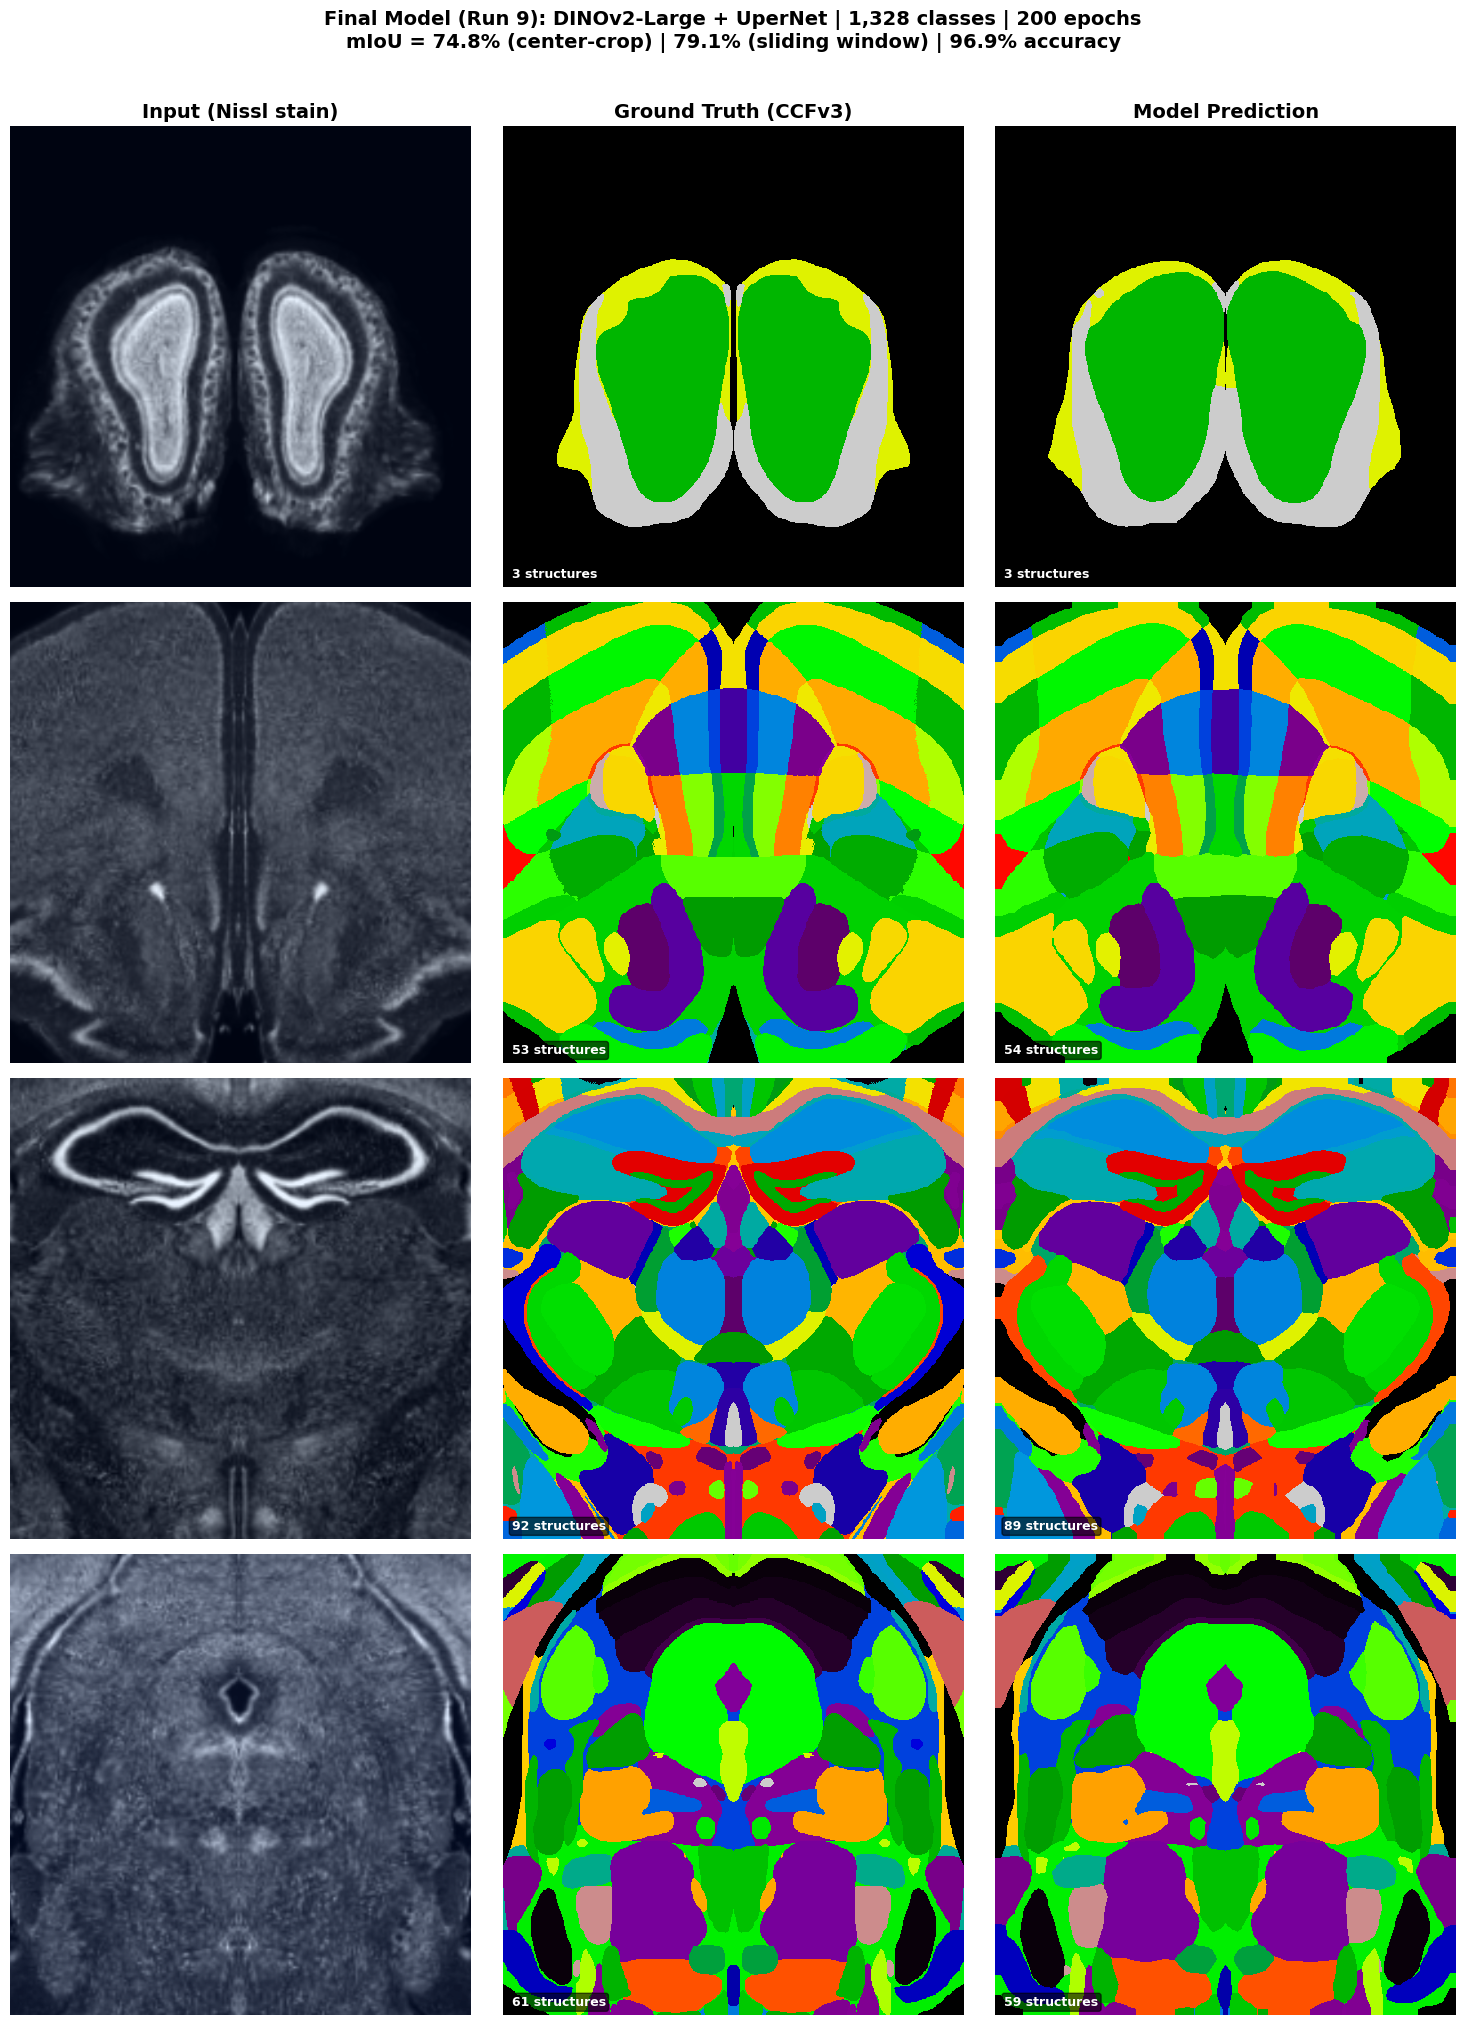

Saved: /dbfs/FileStore/allen_brain_data/figures/fig2_segmentation_examples.png


In [0]:
# Cell 5 — Figure 2: Segmentation Examples (4x3 grid)
#
# 4 representative slices from different rostral-caudal positions,
# each shown as Input / Ground Truth / Prediction.
# Uses val_ds (center-crop, 518x518, no augmentation).

import numpy as np

n_rows = 4
# Evenly space through val set to get anterior -> posterior
indices = [i * (len(val_ds) // n_rows) for i in range(n_rows)]
region_labels = [
    "Anterior\n(Olfactory)",
    "Mid-anterior\n(Striatum, cortex)",
    "Mid-posterior\n(Hippocampus, thalamus)",
    "Posterior\n(Cerebellum, brainstem)",
]

fig, axes = plt.subplots(n_rows, 3, figsize=(15, 5 * n_rows))

for row, (idx, label) in enumerate(zip(indices, region_labels)):
    sample = val_ds[idx]
    pixel_values = sample["pixel_values"].unsqueeze(0).to(device)
    labels = sample["labels"].numpy()

    with torch.no_grad():
        logits = model(pixel_values=pixel_values).logits
        preds = logits.argmax(dim=1).squeeze().cpu().numpy()

    # Denormalize input for display
    img = sample["pixel_values"].permute(1, 2, 0).numpy()
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)

    n_gt = len(np.unique(labels[labels > 0]))
    n_pred = len(np.unique(preds[preds > 0]))

    # Input
    axes[row, 0].imshow(img)
    axes[row, 0].set_ylabel(label, fontsize=11, fontweight="bold",
                             rotation=0, labelpad=100, va="center")
    if row == 0:
        axes[row, 0].set_title("Input (Nissl stain)", fontsize=14,
                                fontweight="bold")
    axes[row, 0].axis("off")

    # Ground truth
    axes[row, 1].imshow(labels, cmap="nipy_spectral", interpolation="nearest")
    if row == 0:
        axes[row, 1].set_title("Ground Truth (CCFv3)", fontsize=14,
                                fontweight="bold")
    axes[row, 1].text(
        0.02, 0.02, f"{n_gt} structures", transform=axes[row, 1].transAxes,
        fontsize=9, color="white", fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.2", facecolor="black", alpha=0.6),
    )
    axes[row, 1].axis("off")

    # Prediction
    axes[row, 2].imshow(preds, cmap="nipy_spectral", interpolation="nearest")
    if row == 0:
        axes[row, 2].set_title("Model Prediction", fontsize=14,
                                fontweight="bold")
    axes[row, 2].text(
        0.02, 0.02, f"{n_pred} structures", transform=axes[row, 2].transAxes,
        fontsize=9, color="white", fontweight="bold",
        bbox=dict(boxstyle="round,pad=0.2", facecolor="black", alpha=0.6),
    )
    axes[row, 2].axis("off")

for ax_row in axes:
    for a in ax_row:
        a.set_aspect("equal")

plt.suptitle(
    "Final Model (Run 9): DINOv2-Large + UperNet | 1,328 classes | 200 epochs\n"
    "mIoU = 74.8% (center-crop) | 79.1% (sliding window) | 96.9% accuracy",
    fontsize=14, fontweight="bold", y=1.01,
)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig2_segmentation_examples.png", dpi=DPI,
            bbox_inches="tight", facecolor="white")
plt.show()
print(f"Saved: {FIGURES_DIR}/fig2_segmentation_examples.png")

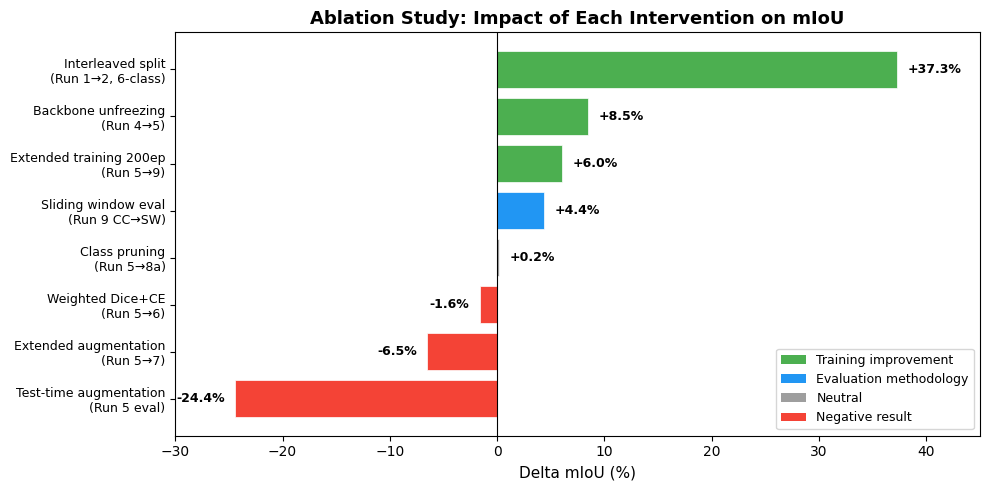

Saved: /dbfs/FileStore/allen_brain_data/figures/fig3_ablation_barchart.png


In [0]:
# Cell 6 — Figure 3: Ablation Bar Chart
#
# Horizontal bars showing delta mIoU for each intervention.
# Hardcoded data from all 9 runs — no model inference needed.

interventions = [
    ("Interleaved split\n(Run 1\u21922, 6-class)", 37.3, "positive"),
    ("Backbone unfreezing\n(Run 4\u21925)", 8.5, "positive"),
    ("Extended training 200ep\n(Run 5\u21929)", 6.0, "positive"),
    ("Sliding window eval\n(Run 9 CC\u2192SW)", 4.4, "method"),
    ("Class pruning\n(Run 5\u21928a)", 0.2, "neutral"),
    ("Weighted Dice+CE\n(Run 5\u21926)", -1.6, "negative"),
    ("Extended augmentation\n(Run 5\u21927)", -6.5, "negative"),
    ("Test-time augmentation\n(Run 5 eval)", -24.4, "negative"),
]

i_labels = [i[0] for i in interventions]
i_values = [i[1] for i in interventions]
i_cats = [i[2] for i in interventions]

color_map = {
    "positive": "#4CAF50",
    "method": "#2196F3",
    "neutral": "#9E9E9E",
    "negative": "#F44336",
}
colors = [color_map[c] for c in i_cats]

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
bars = ax.barh(range(len(i_labels)), i_values, color=colors,
               edgecolor="white", linewidth=0.5)

ax.set_yticks(range(len(i_labels)))
ax.set_yticklabels(i_labels, fontsize=9)
ax.set_xlabel("Delta mIoU (%)", fontsize=11)
ax.set_title("Ablation Study: Impact of Each Intervention on mIoU",
             fontsize=13, fontweight="bold")
ax.axvline(x=0, color="black", linewidth=0.8)
ax.invert_yaxis()

for bar, val in zip(bars, i_values):
    x_pos = bar.get_width()
    offset = 1.0 if val >= 0 else -1.0
    ha = "left" if val >= 0 else "right"
    ax.text(x_pos + offset, bar.get_y() + bar.get_height() / 2,
            f"{val:+.1f}%", ha=ha, va="center", fontsize=9, fontweight="bold")

legend_elements = [
    mpatches.Patch(facecolor="#4CAF50", label="Training improvement"),
    mpatches.Patch(facecolor="#2196F3", label="Evaluation methodology"),
    mpatches.Patch(facecolor="#9E9E9E", label="Neutral"),
    mpatches.Patch(facecolor="#F44336", label="Negative result"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=9)
ax.set_xlim(-30, 45)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig3_ablation_barchart.png", dpi=DPI,
            bbox_inches="tight", facecolor="white")
plt.show()
print(f"Saved: {FIGURES_DIR}/fig3_ablation_barchart.png")

Evaluating 127 validation samples...


Center-crop eval:   0%|          | 0/127 [00:00<?, ?it/s]

Valid classes: 504 / 1328
Mean IoU: 74.4%


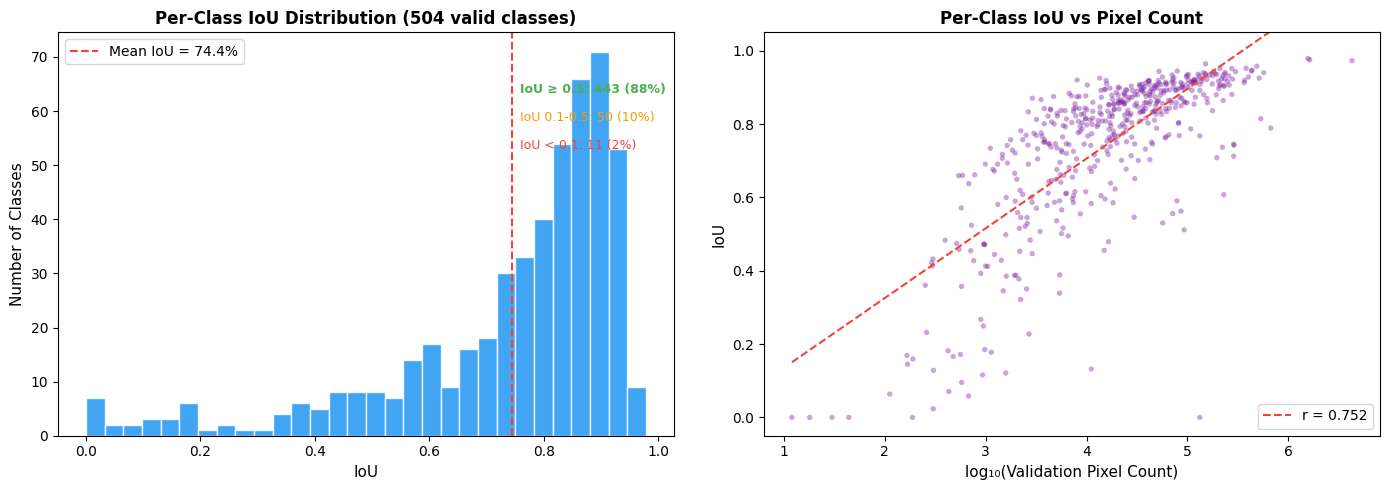

Saved: /dbfs/FileStore/allen_brain_data/figures/fig4_iou_distribution.png


In [0]:
# Cell 7 — Figure 4: Per-Class IoU Distribution
#
# Runs center-crop evaluation on all 127 val samples to compute
# per-class IoU, then plots:
#   Left:  IoU histogram with mean line and bracket counts
#   Right: log10(pixel_count) vs IoU scatter with correlation

from tqdm.auto import tqdm

print(f"Evaluating {len(val_ds)} validation samples...")

class_tp = np.zeros(NUM_LABELS, dtype=np.int64)
class_fp = np.zeros(NUM_LABELS, dtype=np.int64)
class_fn = np.zeros(NUM_LABELS, dtype=np.int64)
class_pixels = np.zeros(NUM_LABELS, dtype=np.int64)

for i in tqdm(range(len(val_ds)), desc="Center-crop eval"):
    sample = val_ds[i]
    pixel_values = sample["pixel_values"].unsqueeze(0).to(device)
    labels = sample["labels"].numpy()

    with torch.no_grad():
        logits = model(pixel_values=pixel_values).logits
        preds = logits.argmax(dim=1).squeeze().cpu().numpy()

    # Only iterate over classes present in this sample
    present = np.unique(np.concatenate([labels.ravel(), preds.ravel()]))
    for cls in present:
        p = preds == cls
        g = labels == cls
        class_tp[cls] += int((p & g).sum())
        class_fp[cls] += int((p & ~g).sum())
        class_fn[cls] += int((~p & g).sum())
        class_pixels[cls] += int(g.sum())

# Compute per-class IoU
eval_class_ious = {}
eval_pixel_counts = {}
for cls in range(NUM_LABELS):
    union = class_tp[cls] + class_fp[cls] + class_fn[cls]
    if union > 0 and class_pixels[cls] > 0:
        eval_class_ious[cls] = float(class_tp[cls]) / float(union)
        eval_pixel_counts[cls] = int(class_pixels[cls])

iou_values = list(eval_class_ious.values())
pixel_values_list = [eval_pixel_counts[c] for c in eval_class_ious]

print(f"Valid classes: {len(eval_class_ious)} / {NUM_LABELS}")
print(f"Mean IoU: {np.mean(iou_values):.1%}")

# --- Plot ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: IoU histogram
ax1.hist(iou_values, bins=30, color="#2196F3", edgecolor="white", alpha=0.85)
mean_iou = np.mean(iou_values)
ax1.axvline(x=mean_iou, color="#F44336", linestyle="--", linewidth=1.5,
            label=f"Mean IoU = {mean_iou:.1%}")
ax1.set_xlabel("IoU", fontsize=11)
ax1.set_ylabel("Number of Classes", fontsize=11)
ax1.set_title(f"Per-Class IoU Distribution ({len(iou_values)} valid classes)",
              fontsize=12, fontweight="bold")
ax1.legend(fontsize=10)

high = sum(1 for v in iou_values if v >= 0.5)
mid = sum(1 for v in iou_values if 0.1 <= v < 0.5)
low = sum(1 for v in iou_values if v < 0.1)
n = len(iou_values)
ax1.text(0.75, 0.85, f"IoU \u2265 0.5: {high} ({high/n:.0%})",
         transform=ax1.transAxes, fontsize=9, color="#4CAF50", fontweight="bold")
ax1.text(0.75, 0.78, f"IoU 0.1-0.5: {mid} ({mid/n:.0%})",
         transform=ax1.transAxes, fontsize=9, color="#FF9800")
ax1.text(0.75, 0.71, f"IoU < 0.1: {low} ({low/n:.0%})",
         transform=ax1.transAxes, fontsize=9, color="#F44336")

# Right: log10(pixel_count) vs IoU scatter
log_pixels = [np.log10(max(p, 1)) for p in pixel_values_list]
ax2.scatter(log_pixels, iou_values, alpha=0.4, s=15, color="#7B1FA2",
            edgecolor="none")

r = np.corrcoef(log_pixels, iou_values)[0, 1]
z = np.polyfit(log_pixels, iou_values, 1)
poly = np.poly1d(z)
x_line = np.linspace(min(log_pixels), max(log_pixels), 100)
ax2.plot(x_line, poly(x_line), color="#F44336", linewidth=1.5, linestyle="--",
         label=f"r = {r:.3f}")

ax2.set_xlabel("log\u2081\u2080(Validation Pixel Count)", fontsize=11)
ax2.set_ylabel("IoU", fontsize=11)
ax2.set_title("Per-Class IoU vs Pixel Count", fontsize=12, fontweight="bold")
ax2.legend(fontsize=10, loc="lower right")
ax2.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig4_iou_distribution.png", dpi=DPI,
            bbox_inches="tight", facecolor="white")
plt.show()
print(f"Saved: {FIGURES_DIR}/fig4_iou_distribution.png")

In [ ]:
# Cell 8 — Inference utilities for raw-slice figures
#
# normalize_tile:           uint8 grayscale -> model-ready tensor
# center_crop_predict_raw:  single raw slice -> center-crop prediction
# sliding_window_predict:   single raw slice -> full-resolution tiled prediction


def normalize_tile(tile):
    """uint8 grayscale (H, W) -> float32 tensor (1, 3, H, W)."""
    img = tile.astype(np.float32) / 255.0
    img_3ch = np.stack([img, img, img], axis=0)
    for c in range(3):
        img_3ch[c] = (img_3ch[c] - IMAGENET_MEAN[c]) / IMAGENET_STD[c]
    return torch.from_numpy(img_3ch).unsqueeze(0)


def center_crop_predict_raw(model, image, crop_size, device):
    """Run center-crop inference on a raw uint8 grayscale image.

    Returns: (prediction array, crop origin (y0, x0))
    """
    h, w = image.shape
    y0 = max(0, (h - crop_size) // 2)
    x0 = max(0, (w - crop_size) // 2)
    crop = image[y0:y0 + crop_size, x0:x0 + crop_size]

    if crop.shape[0] < crop_size or crop.shape[1] < crop_size:
        padded = np.zeros((crop_size, crop_size), dtype=crop.dtype)
        padded[:crop.shape[0], :crop.shape[1]] = crop
        crop = padded

    pixel_values = normalize_tile(crop).to(device)
    model.eval()
    with torch.no_grad():
        logits = model(pixel_values=pixel_values).logits
    pred = logits.argmax(dim=1).squeeze(0).cpu().numpy()
    return pred, (y0, x0)


def sliding_window_predict(model, image, num_labels, crop_size, stride, device):
    """Predict full-resolution segmentation using overlapping tiles.

    Ported from finetune_final_200ep.ipynb Cell 7.
    Works on both GPU (with fp16 autocast) and CPU.
    """
    h, w = image.shape
    pad_h = max(0, crop_size - h)
    pad_w = max(0, crop_size - w)
    if pad_h > 0 or pad_w > 0:
        image = np.pad(image, ((0, pad_h), (0, pad_w)),
                       mode="constant", constant_values=0)
    ph, pw = image.shape

    logit_sum = np.zeros((num_labels, ph, pw), dtype=np.float32)
    count_map = np.zeros((ph, pw), dtype=np.float32)

    y_starts = list(range(0, ph - crop_size + 1, stride))
    x_starts = list(range(0, pw - crop_size + 1, stride))
    if y_starts[-1] + crop_size < ph:
        y_starts.append(ph - crop_size)
    if x_starts[-1] + crop_size < pw:
        x_starts.append(pw - crop_size)

    use_cuda = device.type == "cuda"
    model.eval()
    for y in y_starts:
        for x in x_starts:
            tile = image[y:y + crop_size, x:x + crop_size]
            pv = normalize_tile(tile).to(device)
            with torch.no_grad():
                if use_cuda:
                    with torch.amp.autocast("cuda", dtype=torch.float16):
                        logits = model(pixel_values=pv).logits
                else:
                    logits = model(pixel_values=pv).logits
            tile_logits = logits.squeeze(0).float().cpu().numpy()
            logit_sum[:, y:y + crop_size, x:x + crop_size] += tile_logits
            count_map[y:y + crop_size, x:x + crop_size] += 1.0

    count_map = np.maximum(count_map, 1.0)
    avg_logits = logit_sum / count_map[np.newaxis, :, :]
    pred = avg_logits.argmax(axis=0).astype(np.int64)
    return pred[:h, :w]


print("Inference utilities defined.")

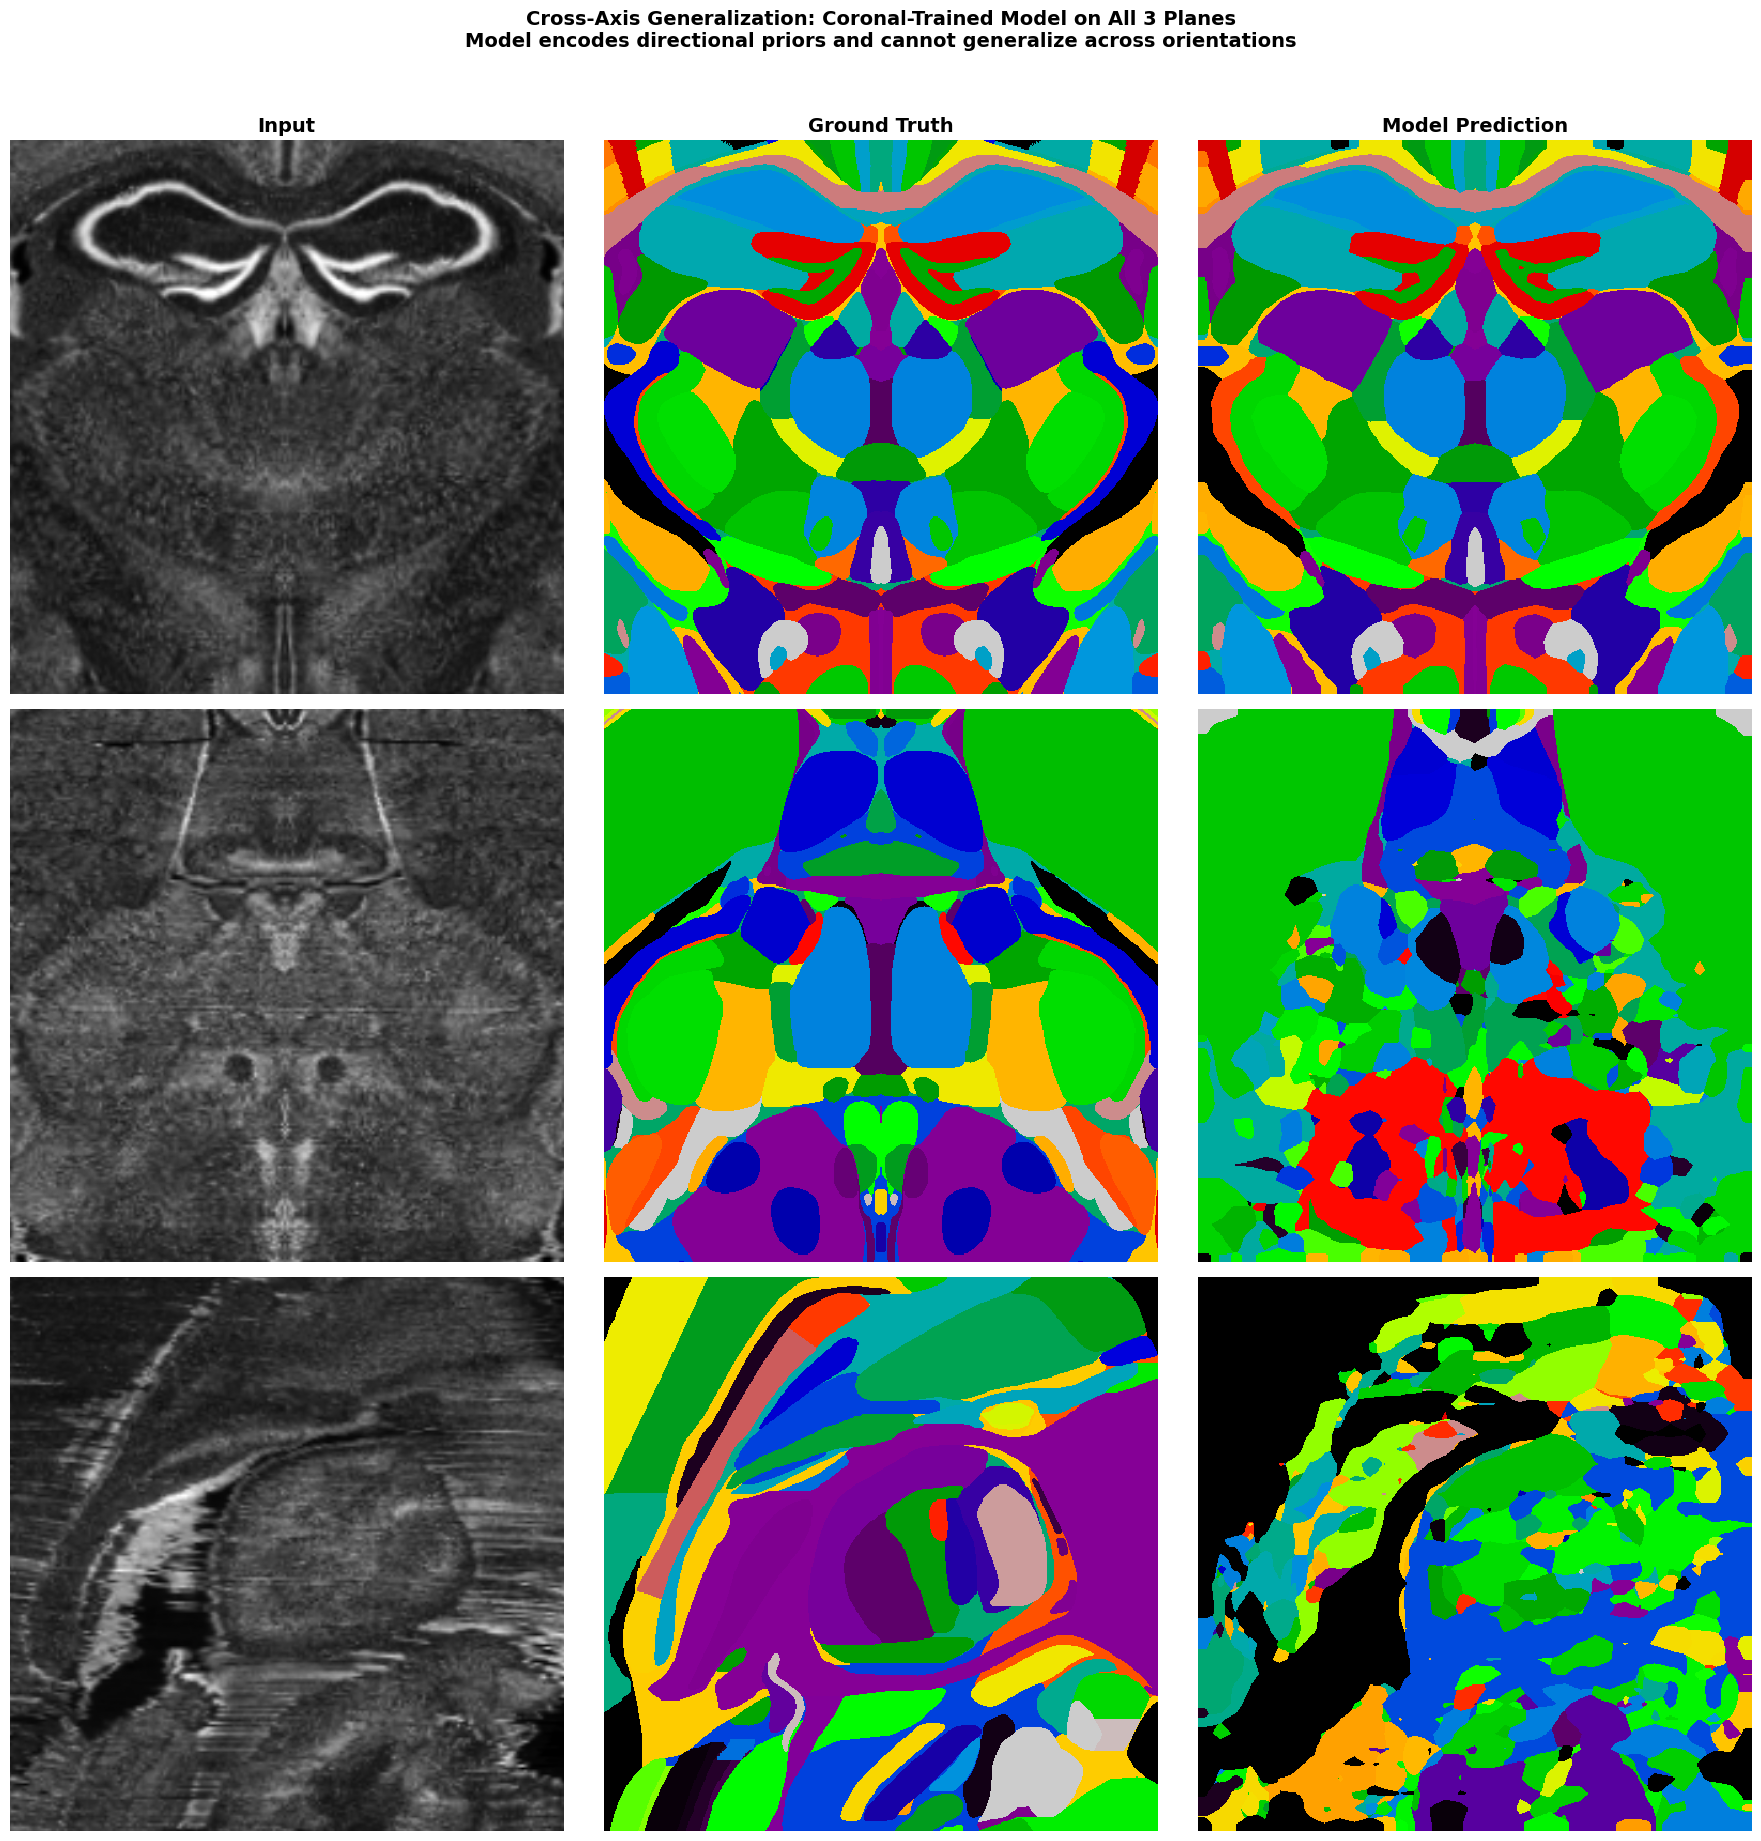

Saved: /dbfs/FileStore/allen_brain_data/figures/fig5_cross_axis.png


In [0]:
# Cell 9 — Figure 5: Cross-Axis Generalization
#
# 3x3 grid: coronal / axial / sagittal x Input / Ground Truth / Prediction.
# Shows that the coronal-trained model fails catastrophically on other planes.

slice_configs = [
    (0, 660, "Coronal (AP=660)\nTrained orientation"),
    (1, 400, "Axial (DV=400)\n3.2% mIoU"),
    (2, 570, "Sagittal (ML=570)\n0.5% mIoU"),
]

fig, axes = plt.subplots(3, 3, figsize=(18, 18))

for row, (axis, idx, title) in enumerate(slice_configs):
    img, annot = slicer.get_slice(idx, axis=axis)
    gt_mask = mapper.remap_mask(annot, mapping)

    # Center crop for prediction
    pred, (y0, x0) = center_crop_predict_raw(model, img, CROP_SIZE, device)
    img_crop = img[y0:y0 + CROP_SIZE, x0:x0 + CROP_SIZE]
    gt_crop = gt_mask[y0:y0 + CROP_SIZE, x0:x0 + CROP_SIZE]

    # Pad if needed
    if img_crop.shape[0] < CROP_SIZE or img_crop.shape[1] < CROP_SIZE:
        p_img = np.zeros((CROP_SIZE, CROP_SIZE), dtype=img_crop.dtype)
        p_img[:img_crop.shape[0], :img_crop.shape[1]] = img_crop
        img_crop = p_img
        p_gt = np.zeros((CROP_SIZE, CROP_SIZE), dtype=gt_crop.dtype)
        p_gt[:gt_crop.shape[0], :gt_crop.shape[1]] = gt_crop
        gt_crop = p_gt

    # Input
    axes[row, 0].imshow(img_crop, cmap="gray")
    axes[row, 0].set_ylabel(title, fontsize=11, fontweight="bold",
                             rotation=0, labelpad=120, va="center")
    if row == 0:
        axes[row, 0].set_title("Input", fontsize=14, fontweight="bold")
    axes[row, 0].axis("off")

    # Ground truth
    axes[row, 1].imshow(gt_crop, cmap="nipy_spectral", interpolation="nearest")
    if row == 0:
        axes[row, 1].set_title("Ground Truth", fontsize=14, fontweight="bold")
    axes[row, 1].axis("off")

    # Prediction
    axes[row, 2].imshow(pred, cmap="nipy_spectral", interpolation="nearest")
    if row == 0:
        axes[row, 2].set_title("Model Prediction", fontsize=14, fontweight="bold")
    axes[row, 2].axis("off")

plt.suptitle(
    "Cross-Axis Generalization: Coronal-Trained Model on All 3 Planes\n"
    "Model encodes directional priors and cannot generalize across orientations",
    fontsize=14, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig5_cross_axis.png", dpi=DPI,
            bbox_inches="tight", facecolor="white")
plt.show()
print(f"Saved: {FIGURES_DIR}/fig5_cross_axis.png")

Running sliding window inference on slice 660...
Done. Prediction shape: (800, 1140)


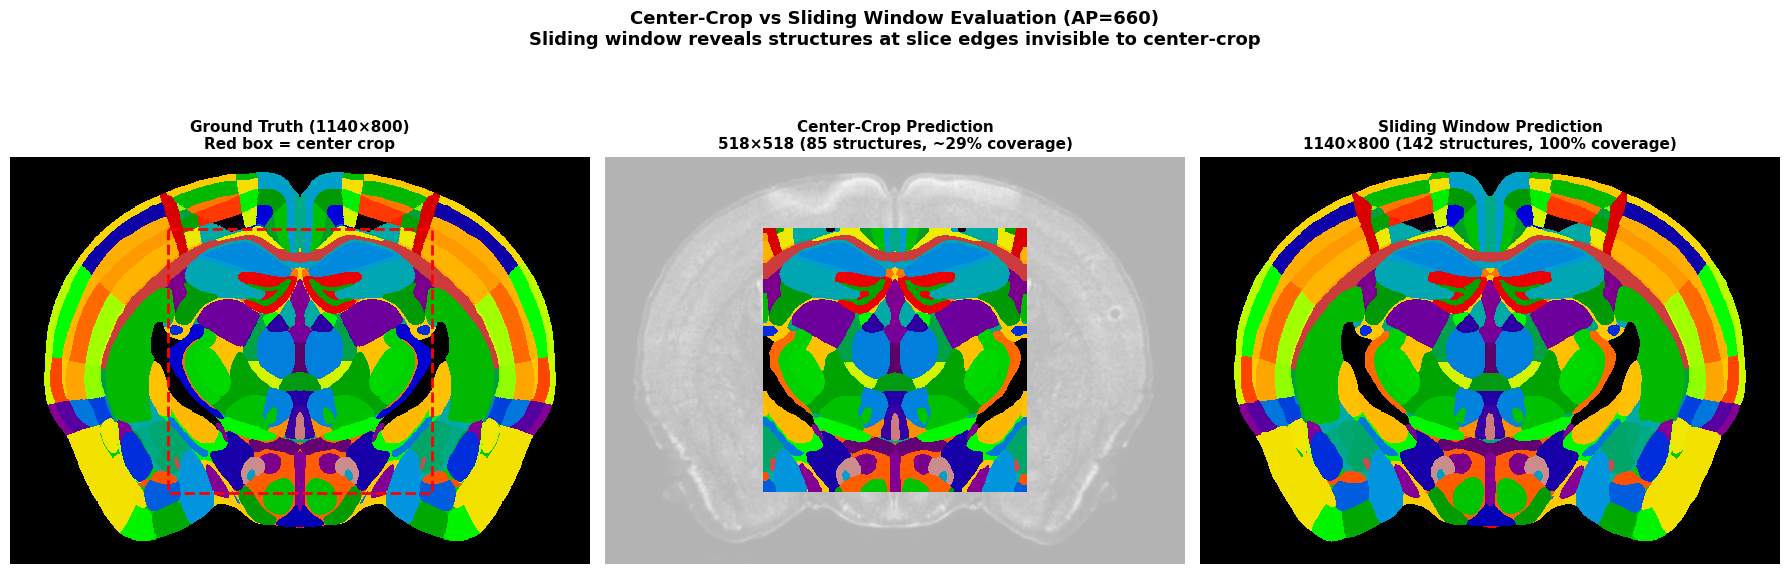

Saved: /dbfs/FileStore/allen_brain_data/figures/fig6_sliding_vs_centercrop.png


In [0]:
# Cell 10 — Figure 6: Sliding Window vs Center-Crop Comparison
#
# 3-panel: Ground Truth (with crop box) / Center-Crop Pred / Sliding Window Pred.
# Shows that sliding window captures structures at slice edges.

SLICE_IDX = 660
STRIDE = CROP_SIZE // 2  # 259 — 50% overlap

img, annot = slicer.get_slice(SLICE_IDX, axis=0)
gt_mask = mapper.remap_mask(annot, mapping)

# Center-crop prediction
cc_pred, (y0, x0) = center_crop_predict_raw(model, img, CROP_SIZE, device)

# Sliding window prediction (full resolution)
print(f"Running sliding window inference on slice {SLICE_IDX}...")
sw_pred = sliding_window_predict(
    model, img, NUM_LABELS, CROP_SIZE, STRIDE, device,
)
print(f"Done. Prediction shape: {sw_pred.shape}")

h, w = img.shape
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Left: ground truth with center-crop box overlay
axes[0].imshow(gt_mask, cmap="nipy_spectral", vmin=0, vmax=NUM_LABELS,
               interpolation="nearest")
rect = plt.Rectangle((x0, y0), CROP_SIZE, CROP_SIZE, linewidth=2,
                      edgecolor="red", facecolor="none", linestyle="--")
axes[0].add_patch(rect)
axes[0].set_title(f"Ground Truth ({w}\u00d7{h})\nRed box = center crop",
                  fontsize=11, fontweight="bold")
axes[0].axis("off")

# Middle: center-crop prediction in full-slice context
axes[1].imshow(img, cmap="gray", alpha=0.3)
cc_display = np.full_like(gt_mask, fill_value=-1, dtype=np.int64)
cc_display[y0:y0 + CROP_SIZE, x0:x0 + CROP_SIZE] = cc_pred
masked = np.ma.masked_where(cc_display < 0, cc_display)
axes[1].imshow(masked, cmap="nipy_spectral", vmin=0, vmax=NUM_LABELS,
               interpolation="nearest")
cc_classes = len(np.unique(cc_pred[cc_pred > 0]))
axes[1].set_title(
    f"Center-Crop Prediction\n518\u00d7518 ({cc_classes} structures, ~29% coverage)",
    fontsize=11, fontweight="bold",
)
axes[1].axis("off")

# Right: sliding window prediction (full resolution)
axes[2].imshow(sw_pred, cmap="nipy_spectral", vmin=0, vmax=NUM_LABELS,
               interpolation="nearest")
sw_classes = len(np.unique(sw_pred[sw_pred > 0]))
axes[2].set_title(
    f"Sliding Window Prediction\n{w}\u00d7{h} ({sw_classes} structures, 100% coverage)",
    fontsize=11, fontweight="bold",
)
axes[2].axis("off")

plt.suptitle(
    f"Center-Crop vs Sliding Window Evaluation (AP={SLICE_IDX})\n"
    "Sliding window reveals structures at slice edges invisible to center-crop",
    fontsize=13, fontweight="bold", y=1.04,
)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/fig6_sliding_vs_centercrop.png", dpi=DPI,
            bbox_inches="tight", facecolor="white")
plt.show()
print(f"Saved: {FIGURES_DIR}/fig6_sliding_vs_centercrop.png")

In [0]:
# Cell 11 — Summary

import os

print("="*65)
print("ALL PAPER FIGURES GENERATED")
print("="*65)

figure_files = [
    ("fig1_architecture.png", "Architecture diagram"),
    ("fig2_segmentation_examples.png", "Segmentation examples (4x3 grid)"),
    ("fig3_ablation_barchart.png", "Ablation bar chart"),
    ("fig4_iou_distribution.png", "IoU distribution + pixel scatter"),
    ("fig5_cross_axis.png", "Cross-axis generalization"),
    ("fig6_sliding_vs_centercrop.png", "Sliding window vs center-crop"),
]

for fname, desc in figure_files:
    path = os.path.join(FIGURES_DIR, fname)
    if os.path.exists(path):
        size_mb = os.path.getsize(path) / 1e6
        print(f"  {fname:45s} {size_mb:6.1f} MB  {desc}")
    else:
        print(f"  {fname:45s}  MISSING   {desc}")

print(f"\nOutput directory: {FIGURES_DIR}")
print("Download with: databricks fs cp -r dbfs:/FileStore/allen_brain_data/figures/ ./figures/")

ALL PAPER FIGURES GENERATED
  fig1_architecture.png                            0.2 MB  Architecture diagram
  fig2_segmentation_examples.png                   5.8 MB  Segmentation examples (4x3 grid)
  fig3_ablation_barchart.png                       0.2 MB  Ablation bar chart
  fig4_iou_distribution.png                        0.3 MB  IoU distribution + pixel scatter
  fig5_cross_axis.png                              1.6 MB  Cross-axis generalization
  fig6_sliding_vs_centercrop.png                   0.7 MB  Sliding window vs center-crop

Output directory: /dbfs/FileStore/allen_brain_data/figures
Download with: databricks fs cp -r dbfs:/FileStore/allen_brain_data/figures/ ./figures/


## Downloading Figures

To download all figures to your local machine:

```bash
databricks fs cp -r dbfs:/FileStore/allen_brain_data/figures/ ./figures/
```

Or download individual files:

```bash
databricks fs cp dbfs:/FileStore/allen_brain_data/figures/fig2_segmentation_examples.png ./figures/
```

The figures are also accessible via the DBFS browser in the Databricks workspace UI.